In [1]:
from maskseg_build_everything import (
    build_maskvar_flex,
    build_maskvar_flex_5_stages,
    build_maskvar_flex_mobile_5_stages,
    build_var_image_encoder,
    build_prompt_encoder,
    build_sam_image_encoder
)
import torch
import torch.nn.functional as F
from datasets.coco_lvis import LvisDataset
from datasets.hqseg44k import HQSeg44KTrainDataset, HQSeg44KTestDataset
from datasets.mask_level_dataset import MaskLevelDataset
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
from datasets import instance_info
import json

/home/clc/miniconda3/envs/var_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/clc/miniconda3/envs/var_v2/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/clc/miniconda3/envs/var_v2/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/data/clc/maskseg/models/tinyvit.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with models.tinyvit.tiny_vit_5m_224. This is becaus

In [2]:
device = 'cuda:0'

In [3]:
def visualize_mask(image, layers, instances_info, alpha=0.5):
    plt.imshow(image // 2)
    # for inst_id, inst_info in instances_info.items():   
    #     if inst_info.parent is None:
    #         masked_data = np.ma.masked_where(layers[:, :, inst_info.mapping[0]] == 0, layers[:, :, inst_info.mapping[0]])
    #         plt.imshow(masked_data, alpha=alpha)
    for l in range(layers.shape[-1]):
        masked_data = np.ma.masked_where(layers[:, :, l] == 0, layers[:, :, l])
        plt.imshow(masked_data, alpha=alpha, cmap='tab20c')
    plt.show()

In [4]:
from models.prompt_encoder import PromptEncoder

vqvae, maskvar, sam_image_encoder = build_maskvar_flex_mobile_5_stages('out_vqvae_5_stages_v1/ckpt/vqvae_single_epoch_50.pth', 'ckpt/mobile_sam.pt', device=device)
maskvar.init_block_mask()

# maskvar_ckpt = torch.load('test-maskvar_flex_mobile_5_stages-3/ar-ckpt-last.pth', map_location=device)
maskvar_ckpt = torch.load('test-maskvar_flex_mobile_5_debug/ar-ckpt-last.pth', map_location=device)
maskvar.load_state_dict(maskvar_ckpt['trainer']['var_wo_ddp'])


[constructor]  ==== (fusing_add_ln=0/4, fusing_mlp=0/4) ==== 
    [VAR config ] embed_dim=256, num_heads=4, depth=4, mlp_ratio=4
    [drop ratios ] drop_rate=0.1, drop_path_rate=0.1 (tensor([0.0000, 0.0333, 0.0667, 0.1000]))



<All keys matched successfully>

In [5]:
# dataset = HQSeg44KTrainDataset(
#     data_root='data/sam-hq',
#     img_size=(256, 256)
# )
dataset = LvisDataset(
    dataset_path='data/coco_lvis',
    split='train',
    img_split='train',
    stuff_prob=0.0,
)

mask_level_dataset = MaskLevelDataset(dataset, sam_encoder=sam_image_encoder, device=device)

data_iter = iter(mask_level_dataset)

In [6]:
image, image_embed_sam, single_mask_normalized, single_mask = next(data_iter)

In [7]:
from utils.clicker import init_clicks, predict_next_click, to_sam_format

single_mask_cpu = single_mask.cpu().numpy()

click_list, eroded_mask, dt = init_clicks(single_mask_cpu[0], num_random_clicks=2)

print(click_list)

coords, labels = to_sam_format(click_list, pad_size=13)
prompt_points_coords = torch.Tensor(coords).to(device)
prompt_points_labels = torch.Tensor(labels).to(device)

# prompt_points_coords = [[[150, 150]]]
# prompt_points_labels = [[1]]

# prompt_points_coords = torch.Tensor(prompt_points_coords).to(device)
# prompt_points_labels = torch.Tensor(prompt_points_labels).to(device)

label_B = torch.zeros(1, dtype=torch.long).to(device)

[(np.int64(57), np.int64(119), 1), (np.int64(44), np.int64(151), 1)]


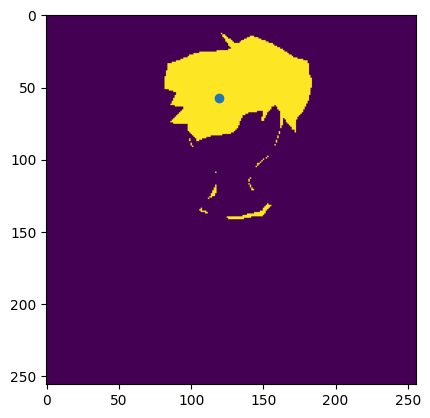

In [8]:
plt.imshow(single_mask.cpu().squeeze(0))
plt.scatter(click_list[0][1], click_list[0][0])

In [9]:
gt_mask = single_mask_normalized.unsqueeze(0)
print(gt_mask.shape)
gt_mask_ids = vqvae.img_to_idxBl(gt_mask)
x_BLCv_wo_first_l = vqvae.quantize.idxBl_to_var_input(gt_mask_ids)

torch.Size([1, 1, 256, 256])


In [10]:
logits = maskvar.forward(label_B=label_B, x_BLCv_wo_first_l=x_BLCv_wo_first_l, sam_image_embedding=image_embed_sam.unsqueeze(0), points_coords=prompt_points_coords.unsqueeze(0), points_labels=prompt_points_labels.unsqueeze(0))

In [11]:
from models.helpers import sample_with_top_k_top_p_
import torchvision
from PIL import Image
import numpy as np

In [12]:
idx = sample_with_top_k_top_p_(logits, top_k=1, num_samples=1)[:, :, 0]

In [13]:
# v_patch_nums=(1, 2, 4, 8, 12, 16, 20, 24, 28, 32)
v_patch_nums = (1, 8, 16, 24, 32)

indices = []
sum = 0
for i, pn in enumerate(v_patch_nums):
    indices.append(idx[:, sum:sum+pn*pn].to(device))
    sum += pn*pn


In [18]:
for ind in gt_mask_ids:
    print(ind.shape, ind)

torch.Size([1, 1]) tensor([[651]], device='cuda:0')
torch.Size([1, 64]) tensor([[2970, 2519, 1952, 4078, 1548, 3064, 4072, 2970, 2970, 1486, 2095,  726,
          301, 1548, 3860, 2970, 2970, 2969, 2364, 2666,  757, 2438, 2503, 2970,
         2970, 4072,  243,  629, 3601, 1895, 4072, 2970, 2970, 4072, 2969,  744,
         2838, 4078, 4072, 2519, 2970, 2970, 4072, 2519, 2503, 2970, 2970, 2519,
         2970, 2970, 2519, 2519, 2970, 2970, 2970, 2970, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519]], device='cuda:0')
torch.Size([1, 256]) tensor([[2519, 2519, 2970, 2367, 3498,  447, 2340,  183, 2823,  492, 3430, 2907,
         2956, 2519, 2519, 2519, 2519, 2519, 2519, 2367,  671,  317, 2662,  348,
          309, 3204, 2470,  757,  873, 2503, 2519, 2519, 2519, 2519, 4072,  744,
         2838, 1459, 3200, 3039,  933, 2838, 2707, 1862, 4078, 2519, 2519, 2519,
         2519, 2519, 2503, 1862, 3664, 3808, 2586, 2172, 3461, 2801, 3567, 2092,
         2620, 3860, 4078, 2519, 2519, 2519, 

In [17]:
for ind in indices:
    print(ind.shape, ind)

torch.Size([1, 1]) tensor([[2970]], device='cuda:0')
torch.Size([1, 64]) tensor([[2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2970, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2970, 2519, 2519, 2519, 2970, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519]], device='cuda:0')
torch.Size([1, 256]) tensor([[2519, 2519, 2519, 2970, 2970, 2519, 2519, 2970, 2970, 2519, 2519, 2519,
         2519, 2970, 2519, 2519, 2519, 2519, 2519, 2970, 2519, 2970, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2970, 2970,
         2970, 2970, 2970, 2519, 2519, 2519, 2970, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2970, 2970, 2970, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519,

5 torch.Size([1, 1024])


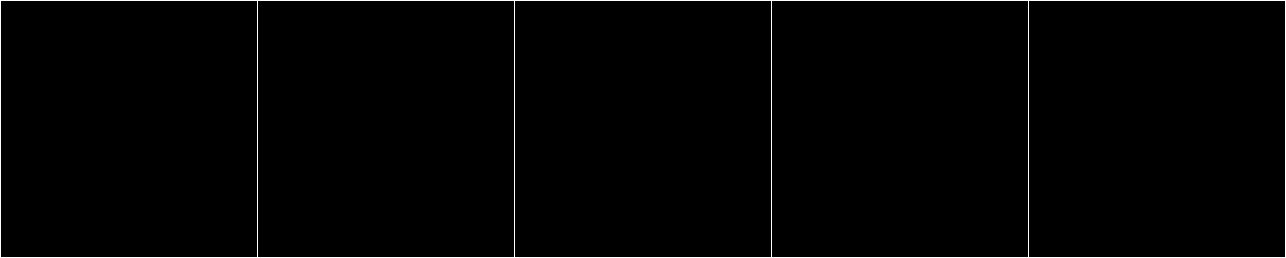

In [15]:
result = vqvae.idxBl_to_img(indices, same_shape=True)
print(len(indices), indices[-1].shape)
# result_conv = [edge(item) for item in result]
result = [(mask > 0).float() for mask in result]
chw = torchvision.utils.make_grid(torch.cat(result[:], dim=0), nrow=5, padding=1, pad_value=1.0)

chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
chw = Image.fromarray(chw.astype(np.uint8))
chw

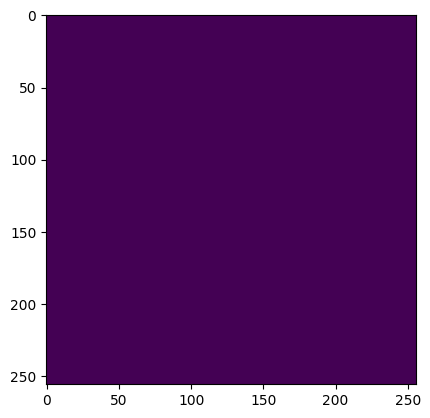

In [16]:
image_out = maskvar.autoregressive_infer_cfg(B=1, label_B=None, sam_image_embedding=image_embed_sam.unsqueeze(0), points_coords=prompt_points_coords.unsqueeze(0), points_labels=prompt_points_labels.unsqueeze(0), top_k=1)
plt.imshow(image_out[0].permute(1, 2, 0).cpu().numpy() > 0)